依据种类划分

In [2]:

### configure the number of available CPU
import os as os

### import some standard libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
### load and define dataframe for the learning dataset
Learning = pd.read_csv("selected_features_Styren.csv") # this contains >500 data points

print('\t')
print('Learning dataset (original): \n')
print(f'Filetype: {type(Learning)}, Shape: {Learning.shape}')
print(Learning)
print(Learning.describe())

### define X and Y out of the learning data (X: features, Y: values)
columns_to_drop = Learning.columns.to_list()  # 获取所有列名
columns_to_drop = ['lnr', 'index', 'Normalized SMILES']  # 选择要删除的列
X = Learning.drop(columns=columns_to_drop, axis=1)
Y = Learning['lnr']

## train and evaluate the model
from sklearn.ensemble import RandomForestRegressor
RFrgs = RandomForestRegressor(random_state=5)
from sklearn.model_selection import cross_val_score, GroupKFold

# 获取组(group)信息
groups = Learning['Normalized SMILES'].values

cross_val = 10
# 创建 GroupKFold 交叉验证器,并设置随机种子
group_kfold = GroupKFold(n_splits=cross_val)

scores = cross_val_score(RFrgs, X, Y, scoring="r2", cv=group_kfold, groups=groups)

def display_score(scores):
    print('\n')
    print('Preliminary run: \n')
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
    
display_score(scores)


	
Learning dataset (original): 

Filetype: <class 'pandas.core.frame.DataFrame'>, Shape: (394, 67)
     MinAbsEStateIndex       qed        SPS    AvgIpc      BalabanJ  \
0             1.150139  0.476114  11.888889  2.588571  3.310000e-07   
1             1.150139  0.476114  11.888889  2.588571  3.310000e-07   
2             1.150139  0.476114  11.888889  2.588571  3.310000e-07   
3             1.150139  0.476114  11.888889  2.588571  3.310000e-07   
4             1.150139  0.476114  11.888889  2.588571  3.310000e-07   
..                 ...       ...        ...       ...           ...   
389           1.167500  0.464102   9.238095  2.929539  4.000000e-07   
390           1.167500  0.464102   9.238095  2.929539  4.000000e-07   
391           1.167500  0.464102   9.238095  2.929539  4.000000e-07   
392           1.167500  0.464102   9.238095  2.929539  4.000000e-07   
393           1.167500  0.464102   9.238095  2.929539  4.000000e-07   

     HallKierAlpha           Ipc    Kappa3  PEOE

In [3]:

### fine tune the model using GridSearchCV
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.model_selection import GridSearchCV, GroupKFold
### fine tune the model using GridSearchCV
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# param_grid = [
#     {'n_estimators': [100, 300, 500],
#       'max_depth': [10, 50, 100,200],
#       'max_features': [64,32,16,8]}
#     ]


param_grid = [
    {'n_estimators': [100],
      'max_depth': [50],
      'max_features': [32]}
]

# 获取组(group)信息
groups = Learning['Normalized SMILES'].values


# 创建 GroupKFold 交叉验证器
group_kfold = GroupKFold(n_splits=10)

# 使用 GroupKFold 进行网格搜索
grid_search = GridSearchCV(RFrgs, param_grid, scoring="r2", cv=group_kfold)
grid_search.fit(X, Y, groups=groups)
print('Best parameters:', grid_search.best_params_)

cvres = grid_search.cv_results_

print('\nHyperparameter tuning: \n')
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)



### re-train the model with the best hyperparameters and the whole training set
RFrgs_opt = grid_search.best_estimator_
model = RFrgs_opt.fit(X, Y)

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Assuming RFrgs_opt is already the optimized RandomForestRegressor model
# and kfold is your KFold cross-validation splitting strategy

# Create scorers for each metric
r2_scorer = make_scorer(r2_score)
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))
mae_scorer = make_scorer(mean_absolute_error)

# Calculate scores for each fold
r2_scores = cross_val_score(model, X, Y, cv=group_kfold, groups=groups, scoring=r2_scorer)
rmse_scores = cross_val_score(model, X, Y, cv=group_kfold, groups=groups, scoring=rmse_scorer)
mae_scores = cross_val_score(model, X, Y, cv=group_kfold, groups=groups,scoring=mae_scorer)

# Print scores for each fold
print('\nQuality assessment for each fold using the model with the best hyperparameters:\n')
for fold_idx, (r2, rmse, mae) in enumerate(zip(r2_scores, rmse_scores, mae_scores), start=1):
    print(f'Fold {fold_idx}:')
    print(f'R2 score: {r2:.4f}')
    print(f'RMSE score: {rmse:.4f}')
    print(f'MAE score: {mae:.4f}\n')

# If you want to print the mean of the scores across all folds, you can do so as follows:
print('Average scores across all folds:')
print(f'Average R2 score: {np.mean(r2_scores):.4f}')
print(f'Average RMSE score: {np.mean(rmse_scores):.4f}')
print(f'Average MAE score: {np.mean(mae_scores):.4f}')



# Best parameters: {'max_depth': 50, 'max_features': 13, 'n_estimators': 100}

Best parameters: {'max_depth': 50, 'max_features': 32, 'n_estimators': 100}

Hyperparameter tuning: 

0.7382793357262329 {'max_depth': 50, 'max_features': 32, 'n_estimators': 100}

Quality assessment for each fold using the model with the best hyperparameters:

Fold 1:
R2 score: 0.8704
RMSE score: 0.2385
MAE score: 0.1953

Fold 2:
R2 score: 0.7074
RMSE score: 0.4007
MAE score: 0.2972

Fold 3:
R2 score: 0.7792
RMSE score: 0.3991
MAE score: 0.3151

Fold 4:
R2 score: 0.7793
RMSE score: 0.5648
MAE score: 0.4658

Fold 5:
R2 score: 0.8353
RMSE score: 0.2884
MAE score: 0.1896

Fold 6:
R2 score: 0.4921
RMSE score: 0.4308
MAE score: 0.3436

Fold 7:
R2 score: 0.6524
RMSE score: 0.4665
MAE score: 0.3693

Fold 8:
R2 score: 0.9053
RMSE score: 0.2986
MAE score: 0.2259

Fold 9:
R2 score: 0.6721
RMSE score: 0.4171
MAE score: 0.3044

Fold 10:
R2 score: 0.6894
RMSE score: 0.3303
MAE score: 0.2881

Average scores across all folds:
Average R2 score: 0.7383
Average RMSE score: 0.3835
Average MAE score: 0.2

In [4]:
from sklearn.model_selection import GridSearchCV


param_grid = [
    {'n_estimators': [100],
      'max_depth': [50],
      'max_features': [32]}
]




# 获取组(group)信息
groups = Learning['Normalized SMILES'].values


# 创建 GroupKFold 交叉验证器
group_kfold = GroupKFold(n_splits=10)

grid_search = GridSearchCV(RFrgs_opt, param_grid, scoring="r2", cv=group_kfold)
grid_search.fit(X, Y, groups=groups)

cvres = grid_search.cv_results_

print('\n')
print('Hyperparameter tuning: \n')
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)

best_model = grid_search.best_estimator_

print('\n')
print('Best model parameters: \n')
print(best_model)

# Re-train the model with the best hyperparameters and the whole training set
final_model = best_model.fit(X, Y)

# Analyze and visualize the optimized model performance on the training set using cross-validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_predict

cv_pred = cross_val_predict(final_model, X, Y, cv=group_kfold, groups=groups)
R2_cv = r2_score(Y, cv_pred)
RMSE_cv = np.sqrt(mean_squared_error(Y, cv_pred))
MAE_cv = mean_absolute_error(Y, cv_pred)

print('\n')
print('Quality assessment with cross-validation (employ model with the best hyperparameters): \n')
print('R2 score: ', R2_cv)
print('RMSE score:', RMSE_cv)
print('MAE score:', MAE_cv)



Hyperparameter tuning: 

0.7382793357262329 {'max_depth': 50, 'max_features': 32, 'n_estimators': 100}


Best model parameters: 

RandomForestRegressor(max_depth=50, max_features=32, random_state=5)


Quality assessment with cross-validation (employ model with the best hyperparameters): 

R2 score:  0.7715953277635251
RMSE score: 0.39439255556645797
MAE score: 0.29958997460576137


<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
<>:14: SyntaxWarning: invalid escape sequence '\g'
<>:15: SyntaxWarning: invalid escape sequence '\g'
C:\Users\ROG\AppData\Local\Temp\ipykernel_31552\255731578.py:14: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel('Experimental ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
C:\Users\ROG\AppData\Local\Temp\ipykernel_31552\255731578.py:15: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Predicted ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)


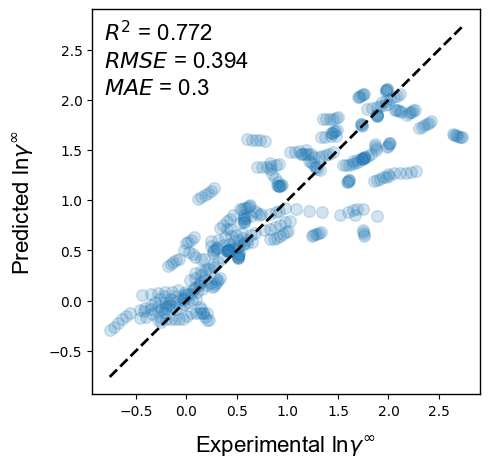

In [5]:
### plot the figure
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111)
for m in ['top', 'bottom', 'left', 'right']:
    ax.spines[m].set_linewidth(1)
    ax.spines[m].set_color('black')
ax.scatter(Y, cv_pred, 70, 'tab:blue', alpha=0.2)
ax.plot([Y.min(), Y.max()], [Y.min(), Y.max()], "k--", lw=2)
import matplotlib.font_manager as fm
fonts = fm.FontProperties(family='arial', size=16, weight='normal', style='normal')
plt.text(0.03, 0.92, '$R^2$ = {}'.format(str(round(R2_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.text(0.03, 0.85, '$RMSE$ = {}'.format(str(round(RMSE_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.text(0.03, 0.78, '$MAE$ = {}'.format(str(round(MAE_cv, 3))), transform=ax.transAxes, fontproperties=fonts)
plt.xlabel('Experimental ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
plt.ylabel('Predicted ln$\gamma^{∞}$', labelpad=10, fontproperties=fonts)
import matplotlib.ticker as mticker
ticker_arg = [10, 20, 10, 20]
tickers = [mticker.MultipleLocator(ticker_arg[i]) for i in range(len(ticker_arg))]

